<a href="https://colab.research.google.com/github/PrasannaGiri17/AI2/blob/main/2408641_PrasannaGiri_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis — Movie Review Classification using RNN, LSTM, and Word2Vec

**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Assignment:** Part III – Language Task (Final Portfolio Assessment)  
**Dataset:** Movie Review Dataset (`train_movie_review.csv`, `val_movie_review.csv`, `test_movie_review.csv`)

This notebook implements end-to-end sentiment analysis for binary classification (Positive / Negative) using:

- **Model 1:** Simple RNN with trainable Embedding layer  
- **Model 2:** LSTM with trainable Embedding layer  
- **Model 3:** LSTM with pretrained GloVe (Word2Vec-style) embeddings  
- **Bonus:** Gradio GUI for real-time prediction



## 1. Setup and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install all dependencies
!pip install -q numpy==1.23.5
!pip install -q gensim
!pip install -q gradio
!pip install -q contractions wordcloud

import os, re, time, random, string, warnings
warnings.filterwarnings('ignore')                    # Suppress warning messages

import numpy as np                                   # Numerical operations
import pandas as pd                                  # Data manipulation
import matplotlib.pyplot as plt                      # Plotting and visualization
import seaborn as sns                                # Statistical visualizations
from wordcloud import WordCloud                      # Generate word clouds
from collections import Counter                      # Count frequencies

import tensorflow as tf                              # Deep learning framework
from tensorflow import keras                         # High-level neural network API
from tensorflow.keras import layers, callbacks       # NN layers and callbacks
from tensorflow.keras.preprocessing.text import Tokenizer      # Convert text to sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Pad sequences to equal length
from tensorflow.keras.models import Sequential       # Linear stack of layers
from tensorflow.keras.optimizers import Adam         # Adam optimizer

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Evaluation metrics
from sklearn.model_selection import train_test_split  # Split data into train/test

import nltk                                           # Natural language toolkit
nltk.download('stopwords', quiet=True)               # Common stopwords (the, a, an)
nltk.download('wordnet',   quiet=True)               # WordNet lemmatization
nltk.download('omw-1.4',   quiet=True)               # Open Multilingual WordNet
from nltk.corpus import stopwords                    # Stopwords list
from nltk.stem  import WordNetLemmatizer             # Lemmatizer for word normalization

import contractions                                  # Expand contractions (don't → do not)

# Reproducibility - ensures same results every run
SEED = 42
random.seed(SEED)          # Python random seed
np.random.seed(SEED)       # NumPy random seed
tf.random.set_seed(SEED)   # TensorFlow random seed

print('TensorFlow version :', tf.__version__)        # Check TF version
print('GPU available      :', tf.config.list_physical_devices('GPU'))  # Verify GPU

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.6 MB/s eta 0:00:00
TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


A. Text Preprocessing, Tokenization, and Sequence Padding:

1.1 Load the dataset and preview

The dataset comes as three separate CSVs: `train_movie_review.csv`, `val_movie_review.csv`, `test_movie_review.csv`.  
Each file contains columns **`review`** (text) and **`sentiment`** (1 = Positive, 0 = Negative).

In [3]:
import os, zipfile

zip_path     = "/content/drive/MyDrive/5. Movie Review Dataset.zip"

# Destination folder for extraction
extract_path = "/content/data"

# Check if already extracted
if os.path.isdir(extract_path):
    print(f"Already extracted → {extract_path}\n")
else:
    print("Extracting zip …")
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
    print(f"Done. Extracted to → {extract_path}\n")

# Walk through extracted directory and display folder structure
for root, dirs, files in os.walk(extract_path):
    depth = root.replace(extract_path, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth <= 2:
        for f in files:
            print(f"{'  ' * (depth + 1)}{f}")

DATA_DIR = "/content/data/5. Movie Review Dataset/"

for fname in ["train_movie_review.csv", "val_movie_review.csv", "test_movie_review.csv"]:
    fpath = os.path.join(DATA_DIR, fname)
    status = "FOUND" if os.path.isfile(fpath) else "MISSING"
    print(f"[{status}] {fpath}")

Extracting zip …
Done. Extracted to → /content/data

data/
  5. Movie Review Dataset/
    test_movie_review.csv
    5.Description Movie Review Dataset.txt
    train_movie_review.csv
    val_movie_review.csv
[FOUND] /content/data/5. Movie Review Dataset/train_movie_review.csv
[FOUND] /content/data/5. Movie Review Dataset/val_movie_review.csv
[FOUND] /content/data/5. Movie Review Dataset/test_movie_review.csv


1.2 Load Train, Validation and Test Sets

In [4]:
# load training, validation, test dataset
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_movie_review.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_movie_review.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_movie_review.csv"))

# Combine all datasets into single DataFrame for analysis
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"\ntrain : {train_df.shape}")
print(f"val   : {val_df.shape}")
print(f"test  : {test_df.shape}")
print(f"total : {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(df.head(3))


train : (35000, 3)
val   : (5000, 3)
test  : (10000, 3)
total : (50000, 3)

Columns: ['Unnamed: 0', 'review', 'sentiment']
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0


1.3 Exploratory Data Analysis (EDA)

Train: 35,000 rows | Val: 5,000 rows | Test: 10,000 rows
Columns: ['unnamed: 0', 'review', 'sentiment']

=== Train class distribution ===
sentiment
0    17584
1    17416
Name: count, dtype: int64

=== Val class distribution ===
sentiment
1    2545
0    2455
Name: count, dtype: int64

=== Test class distribution ===
sentiment
1    5039
0    4961
Name: count, dtype: int64


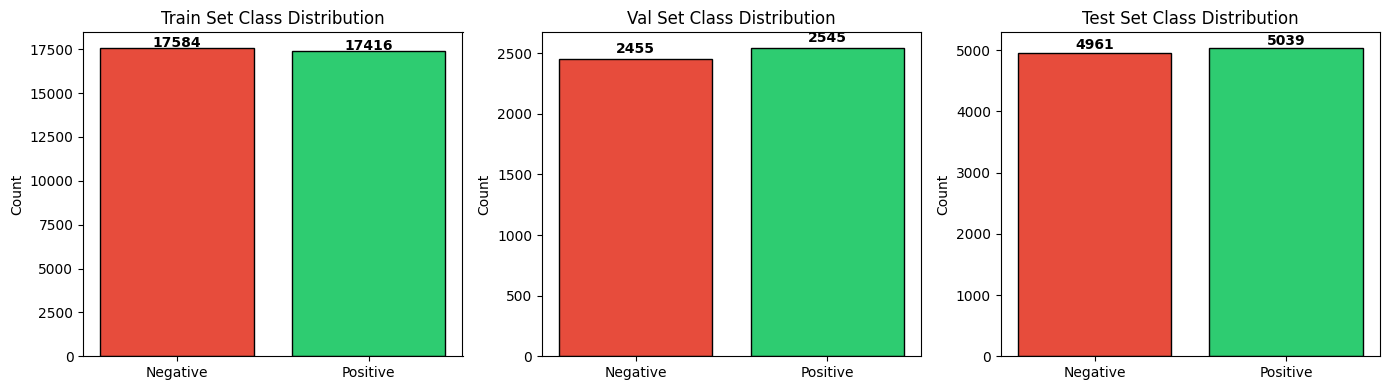


Review length stats (words):
count    35000.000000
mean       230.728714
std        170.956346
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names (strip whitespace and lowercase)
for df in [train_df, val_df, test_df]:
    df.columns = [c.strip().lower() for c in df.columns]

# Print dataset sizes and column names
print(f"Train: {len(train_df):,} rows | Val: {len(val_df):,} rows | Test: {len(test_df):,} rows")
print("Columns:", train_df.columns.tolist())

# Display class distribution for each dataset
print('\n=== Train class distribution ===')
print(train_df['sentiment'].value_counts())
print('\n=== Val class distribution ===')
print(val_df['sentiment'].value_counts())
print('\n=== Test class distribution ===')
print(test_df['sentiment'].value_counts())

# Create bar charts for class distribution across all three sets
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
label_map = {0: 'Negative', 1: 'Positive'}
for ax, (df, title) in zip(axes, [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar([label_map[i] for i in counts.index], counts.values,
           color=['#e74c3c','#2ecc71'], edgecolor='black')
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Calculate review length statistics (number of words per review)
train_df['review_length'] = train_df['review'].astype(str).apply(lambda x: len(x.split()))

print('\nReview length stats (words):')
print(train_df['review_length'].describe())

2. Clean the text

In [6]:
import re
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources (silent mode)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)

# Initialize NLTK tools
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

# Define text cleaning function
def clean_text(text: str) -> str:
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    # 4. Expand contractions (must happen before special-char removal)
    text = contractions.fix(text)
    # 5. Remove numbers and special characters (keep only letters & spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 6. Tokenise, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 1
    ]
    return ' '.join(tokens)

# Apply cleaning function to all datasets
train_df['cleaned_text'] = train_df['review'].astype(str).apply(clean_text)
val_df['cleaned_text']   = val_df['review'].astype(str).apply(clean_text)
test_df['cleaned_text']  = test_df['review'].astype(str).apply(clean_text)

# Combine all data for analysis
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(df[['review', 'cleaned_text']].head(10))

                                              review  \
0  Having avoided seeing the movie in the cinema,...   
1  With this movie I was really hoping that the i...   
2  Raymond Burr stars as an attorney caught up in...   
3  A lot people get hung up on this films tag as ...   
4  I was a fan of Buffy and hoped it would come t...   
5  Arthur is middle aged rich 'kid' who drinks li...   
6  Best fan boy movie I've ever watched save "Fre...   
7  "The King is Alive" is a flawed and contrived ...   
8  Note that I did not say that it is better...ju...   
9  I'm a huge Zack Allan fan and was disappointed...   

                                        cleaned_text  
0  avoided seeing movie cinema buying dvd wife xm...  
1  movie really hoping idea make hashed together ...  
2  raymond burr star attorney caught murder best ...  
3  lot people get hung film tag childrens film ce...  
4  fan buffy hoped would come proper end angel go...  
5  arthur middle aged rich kid drink like fish ar... 

3. Data Visualisation (Word Cloud & Top Words)

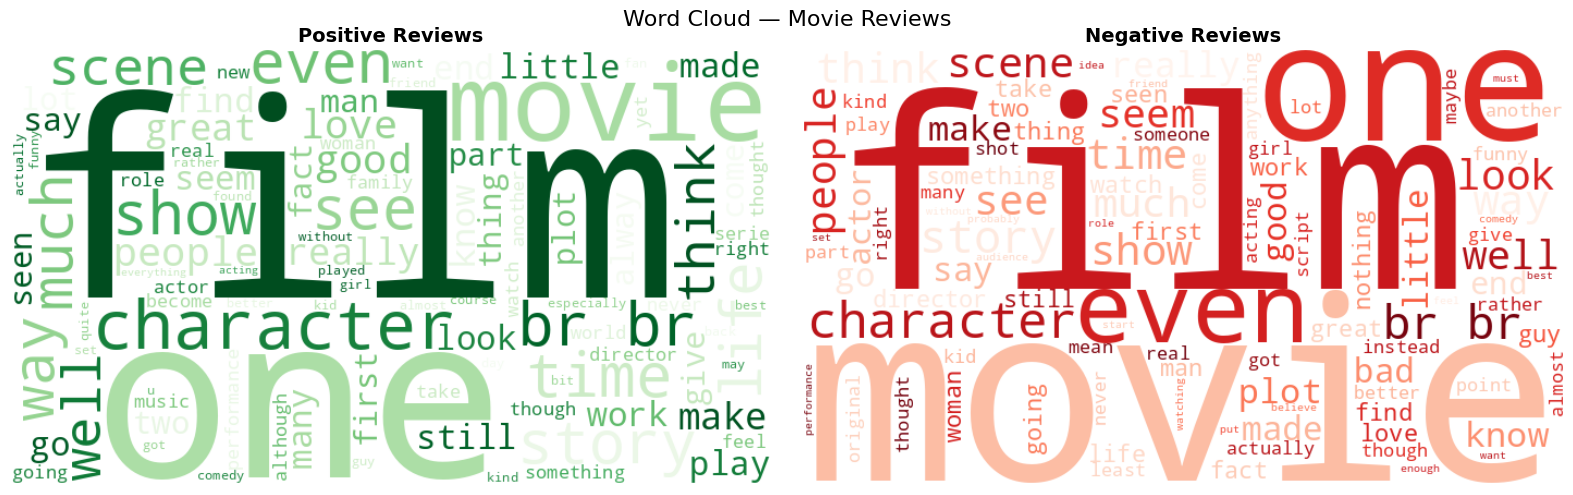

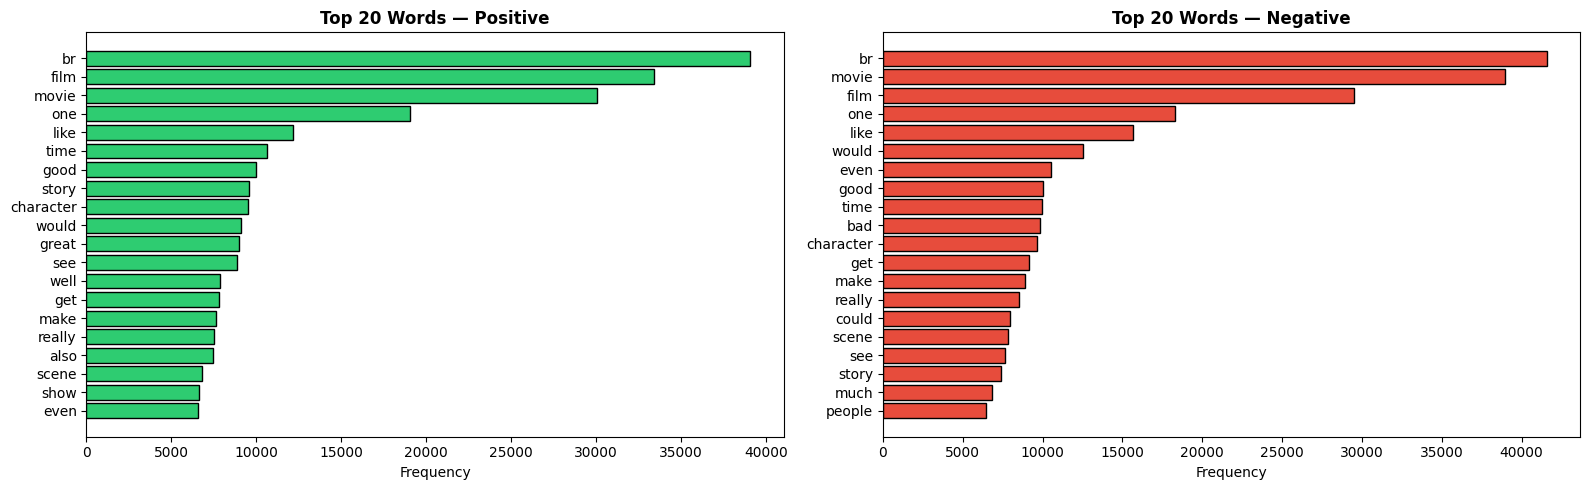

In [7]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Combine all cleaned text for positive and negative reviews separately
pos_text = ' '.join(train_df[train_df['sentiment']==1]['cleaned_text'])
neg_text = ' '.join(train_df[train_df['sentiment']==0]['cleaned_text'])

# Create word clouds for both sentiment classes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, title, color in zip(
    axes,
    [pos_text, neg_text],
    ['Positive Reviews', 'Negative Reviews'],
    ['Greens', 'Reds']
):
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.suptitle('Word Cloud — Movie Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

# Create horizontal bar charts for top 20 words in each sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, title, colour in zip(
    axes,
    [pos_text, neg_text],
    ['Top 20 Words — Positive', 'Top 20 Words — Negative'],
    ['#2ecc71', '#e74c3c']
):
    top = Counter(text.split()).most_common(20)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=colour, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

4. Tokenization and Padding

4.1 Split the dataset

In [8]:
from sklearn.model_selection import train_test_split

df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)

train_df, test_df = train_test_split(df_all, test_size=0.2,
                                     random_state=42,
                                     stratify=df_all['sentiment'])

train_df, val_df = train_test_split(train_df, test_size=0.125,
                                    random_state=42,
                                    stratify=train_df['sentiment'])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Split done using train_test_split ")

Split done using train_test_split 


In [9]:
# Calculate total number of samples across all splits
total = len(train_df) + len(val_df) + len(test_df)

# Calculate percentage for each split
train_pct = len(train_df) / total
val_pct   = len(val_df)   / total
test_pct  = len(test_df)  / total

print(f"Total samples : {total:,}")
print(f"Train         : {len(train_df):,}  ({train_pct:.1%})")
print(f"Val           : {len(val_df):,}    ({val_pct:.1%})")
print(f"Test          : {len(test_df):,}   ({test_pct:.1%})")
print(f"Train+Val     : {train_pct + val_pct:.1%}  ← effective training data (should be ~80%)")

# Verify split follows typical ML convention (80/20 or 70/30)
assert (train_pct + val_pct) >= 0.78, "Training data is below 78% — check your split!"
print("\n Split verified: train+val ≥ 80%, test ≈ 20%")

Total samples : 50,000
Train         : 35,000  (70.0%)
Val           : 5,000    (10.0%)
Test          : 10,000   (20.0%)
Train+Val     : 80.0%  ← effective training data (should be ~80%)

 Split verified: train+val ≥ 80%, test ≈ 20%


4.2 Tokenization & Sequence Padding

In [10]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set vocabulary size limit and out-of-vocabulary token
VOCAB_SIZE = 20000
OOV_TOKEN  = '<OOV>'

# Initialize and train tokenizer on cleaned training reviews
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['cleaned_text'])

# Get total unique vocabulary size
word_index = tokenizer.word_index
print(f'Vocabulary size (total unique): {len(word_index):,}')
print(f'Capped at top {VOCAB_SIZE:,} words for training')

# Determine optimal sequence length using 95th percentile of review lengths
train_lens = train_df['cleaned_text'].apply(lambda x: len(x.split()))
MAX_LEN    = int(np.percentile(train_lens, 95))
print(f'Padding length (95th percentile): {MAX_LEN} tokens')

# Function to convert text to padded sequences
def encode_and_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

# Encode all datasets
X_train = encode_and_pad(train_df['cleaned_text'])
X_val   = encode_and_pad(val_df['cleaned_text'])
X_test  = encode_and_pad(test_df['cleaned_text'])

# Extract labels
y_train    = train_df['sentiment'].values
y_val      = val_df['sentiment'].values
y_test     = test_df['sentiment'].values

# Keep raw test reviews for later inspection
X_test_raw = test_df['review'].values

# Verify encoded shapes
print(f'\nX_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'X_test  shape : {X_test.shape}')

# Embedding layer input dimension (add 1 for padding index 0)
EMBED_INPUT_DIM = VOCAB_SIZE + 1
print(f'\nEmbedding input_dim set to: {EMBED_INPUT_DIM} (VOCAB_SIZE + 1)')

Vocabulary size (total unique): 133,452
Capped at top 20,000 words for training
Padding length (95th percentile): 310 tokens

X_train shape : (35000, 310)
X_val   shape : (5000, 310)
X_test  shape : (10000, 310)

Embedding input_dim set to: 20001 (VOCAB_SIZE + 1)


B. Model Building

1. Hyperparameters & Callbacks

In [11]:
import time
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam

# Model hyperparameters
EMBEDDING_DIM  = 128 # Word embedding dimension
RNN_UNITS      = 64  # Units in RNN layer
LSTM_UNITS     = 64  # Units in LSTM layer
DENSE_UNITS    = 32  # Units in dense layer
DROPOUT_RATE   = 0.3 # Dropout fraction to prevent overfitting
BATCH_SIZE     = 128 # Samples per training batch
MAX_EPOCHS     = 10  # Maximum training epochs

# Define callbacks for training
def make_callbacks():
    # Fresh callback objects for each model — prevents stale EarlyStopping
    # state (old .best / .wait values) from stopping model 2 & 3 too early
    es  = callbacks.EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    )
    rlr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    )
    return [es, rlr]

# Print hyperparameter summary
print("Hyperparameters and callbacks set.")
print(f"  EMBEDDING_DIM : {EMBEDDING_DIM}")
print(f"  MAX_EPOCHS    : {MAX_EPOCHS}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")
print(f"  DROPOUT_RATE  : {DROPOUT_RATE}")
print(f"  EarlyStopping : patience=4, monitor=val_loss")
print(f"  ReduceLROnPlateau: factor=0.5, patience=2")

Hyperparameters and callbacks set.
  EMBEDDING_DIM : 128
  MAX_EPOCHS    : 10
  BATCH_SIZE    : 128
  DROPOUT_RATE  : 0.3
  EarlyStopping : patience=4, monitor=val_loss
  ReduceLROnPlateau: factor=0.5, patience=2


2. Model 1 — Simple RNN with trainable Embedding

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Build SimpleRNN model
rnn_model = Sequential(name='SimpleRNN_Model', layers=[
     # Embedding layer - converts word indices to dense vectors
    layers.Embedding(input_dim=EMBED_INPUT_DIM, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN,
                     mask_zero=True,        # ✅ ignore padding tokens
                     name='embedding_rnn'),

      # Simple RNN layer - processes sequence and captures temporal dependencies
    layers.SimpleRNN(RNN_UNITS,
                     recurrent_dropout=0.2, # ✅ regularise recurrent connections
                     return_sequences=False,
                     name='simple_rnn'),

     # Dropout for regularization
    layers.Dropout(DROPOUT_RATE),

    # Dense layer for feature extraction
    layers.Dense(DENSE_UNITS, activation='relu', name='dense1'),

    # Another dropout layer
    layers.Dropout(DROPOUT_RATE),

    # Output layer - sigmoid for binary classification (positive/negative)
    layers.Dense(1, activation='sigmoid', name='output')
])


# Compile the model
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4, clipnorm=1.0),
    metrics=['accuracy']
)

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

3. Model 2 — LSTM with trainable Embedding

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Build LSTM model
lstm_model = Sequential(name='LSTM_Model', layers=[
    # Embedding layer - converts word indices to dense vectors
    layers.Embedding(input_dim=EMBED_INPUT_DIM, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN,
                     mask_zero=True,        # ✅ ignore padding tokens
                     name='embedding_lstm'),

     # LSTM layer - better at capturing long-range dependencies than SimpleRNN
    layers.LSTM(LSTM_UNITS,
                recurrent_dropout=0.2,      # regularise recurrent connections to prevent overfiting
                return_sequences=False,
                name='lstm'),

    # Dropout for regularization
    layers.Dropout(DROPOUT_RATE),

    # Dense layer for feature extraction
    layers.Dense(DENSE_UNITS, activation='relu', name='dense1'),

    # Another dropout layer
    layers.Dropout(DROPOUT_RATE),

     # Output layer - sigmoid for binary classification (positive/negative)
    layers.Dense(1, activation='sigmoid', name='output')
])

# Compile the model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

4. Model 3 — LSTM + Word2Vec

In [14]:
import numpy as np
import gensim.downloader as api
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Download pre-trained Google News Word2Vec embeddings (300-dim)
print('Downloading Word2Vec embeddings (word2vec-google-news-300)...')
print('Note: ~1.6 GB download, may take a few minutes on first run...')
w2v_model = api.load('word2vec-google-news-300')
W2V_DIM   = 300
print('Download complete.')

# Build embedding matrix from Word2Vec
embedding_matrix = np.zeros((EMBED_INPUT_DIM, W2V_DIM))
hits = 0

# Fill embedding matrix with Word2Vec vectors where available
for word, idx in word_index.items():
    if idx >= EMBED_INPUT_DIM:
        continue
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        hits += 1

# Calculate vocabulary coverage percentage
coverage = hits / min(VOCAB_SIZE, len(word_index)) * 100
print(f'Word2Vec vocabulary coverage : {hits:,} / {min(VOCAB_SIZE, len(word_index)):,} ({coverage:.1f}%)')

# LSTM with pretrained Word2Vec embeddings
lstm_w2v = Sequential(name='LSTM_Word2Vec_Model', layers=[
    layers.Embedding(
        input_dim=EMBED_INPUT_DIM,
        output_dim=W2V_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,
        mask_zero=True,
        name='w2v_embedding'
    ),
    layers.LSTM(LSTM_UNITS,
                recurrent_dropout=0.2,
                return_sequences=False,
                name='lstm'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(DENSE_UNITS, activation='relu', name='dense1'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(1, activation='sigmoid', name='output')
])

# Compile model with binary crossentropy loss
lstm_w2v.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

lstm_w2v.summary()

Note: ~1.6 GB download, may take a few minutes on first run...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Download complete.
Word2Vec vocabulary coverage : 16,662 / 20,000 (83.3%)


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ ?                      │     6,000,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,300 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,300 (22.89 MB)

C. Model Training:

1. Training

In [15]:
import time

# Train Simple RNN model
print('Training Model 1 — Simple RNN ...')
t0 = time.time()
hist_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
rnn_time = time.time() - t0
print(f'Training time: {rnn_time:.1f}s')

Training Model 1 — Simple RNN ...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.5017 - loss: 0.7154 - val_accuracy: 0.4992 - val_loss: 0.6936 - learning_rate: 3.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.5071 - loss: 0.7029 - val_accuracy: 0.5016 - val_loss: 0.6922 - learning_rate: 3.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.5091 - loss: 0.6984 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 3.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5105 - loss: 0.6968
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5109 - loss: 0.6960 - val_accuracy: 0.5016 - val_loss: 0.6927 - learning_rate: 3.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5109 - loss: 0.6948 - val_accuracy: 0.5010 - val_loss: 0.6928 - learning_rate: 1.5000e-04
Epoch 6/10
273/274 ━━━━━━

In [16]:
import time

# Train LSTM model
print('Training Model 2 — LSTM ...')
t0 = time.time()
hist_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
lstm_time = time.time() - t0
print(f'Training time: {lstm_time:.1f}s')

Training Model 2 — LSTM ...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.7503 - loss: 0.5237 - val_accuracy: 0.8782 - val_loss: 0.3073 - learning_rate: 3.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.8905 - loss: 0.2953 - val_accuracy: 0.8834 - val_loss: 0.2849 - learning_rate: 3.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.9046 - loss: 0.2543 - val_accuracy: 0.8816 - val_loss: 0.2913 - learning_rate: 3.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9241 - loss: 0.2153
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
274/274 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.9274 - loss: 0.2070 - val_accuracy: 0.8734 - val_loss: 0.3160 - learning_rate: 3.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - accuracy: 0.9449 - loss: 0.1625 - val_accuracy: 0.8742 - val_loss: 0.3348 - learning_rate: 1.5000e-04
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━

In [17]:
import time

# Train LSTM with GloVe/Word2Vec embeddings
print('Training Model 3 — LSTM + GloVe ...')
t0 = time.time()
hist_w2v = lstm_w2v.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1
)
w2v_time = time.time() - t0
print(f'Training time: {w2v_time:.1f}s')

Training Model 3 — LSTM + GloVe ...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 0.7225 - loss: 0.5569 - val_accuracy: 0.8188 - val_loss: 0.4163 - learning_rate: 3.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.8065 - loss: 0.4479 - val_accuracy: 0.8264 - val_loss: 0.3926 - learning_rate: 3.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.8210 - loss: 0.4175 - val_accuracy: 0.8372 - val_loss: 0.3671 - learning_rate: 3.0000e-04
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.8283 - loss: 0.3996 - val_accuracy: 0.8398 - val_loss: 0.3610 - learning_rate: 3.0000e-04
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8343 - loss: 0.3878 - val_accuracy: 0.8506 - val_loss: 0.3439 - learning_rate: 3.0000e-04
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.8390 - loss: 0.3770 - val_accuracy: 0.8482 - val_loss: 0.3432 - learning_rate: 3.0000e-04
Epoch 7/10
274/274 ━━━

2. Visualization:

Plot the Training vs. Validation loss and accuracy over epochs.

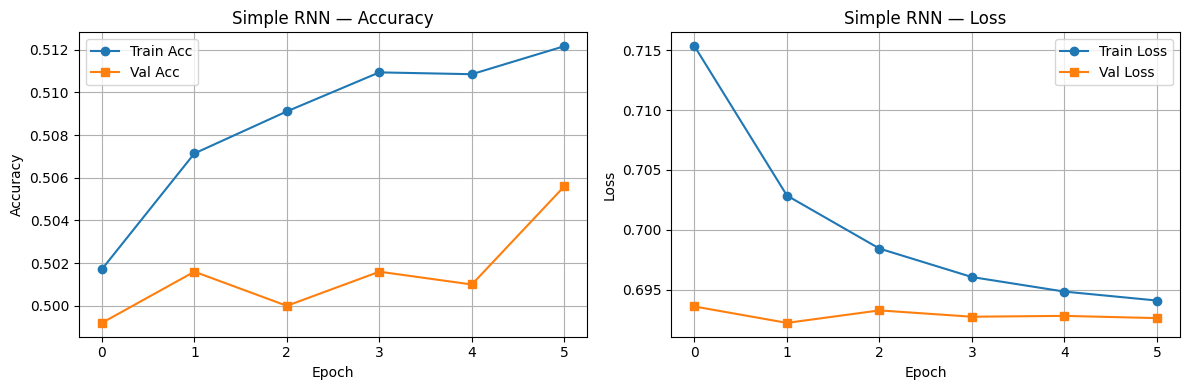

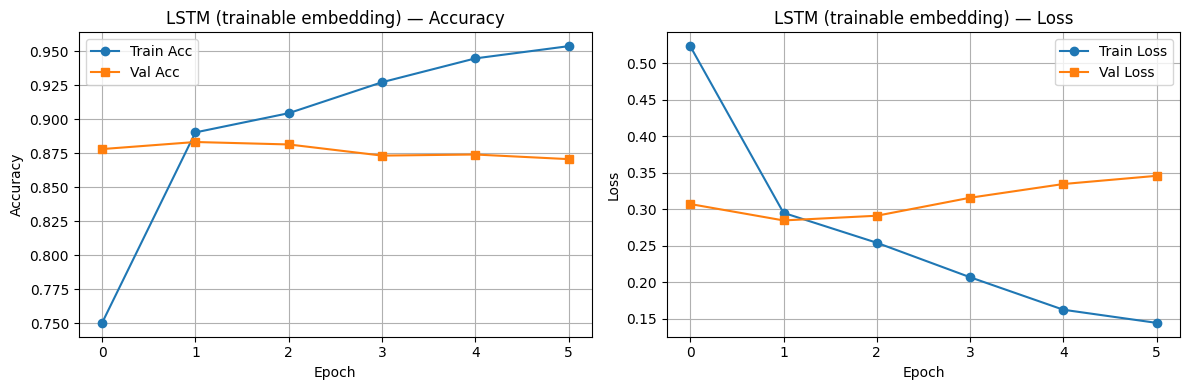

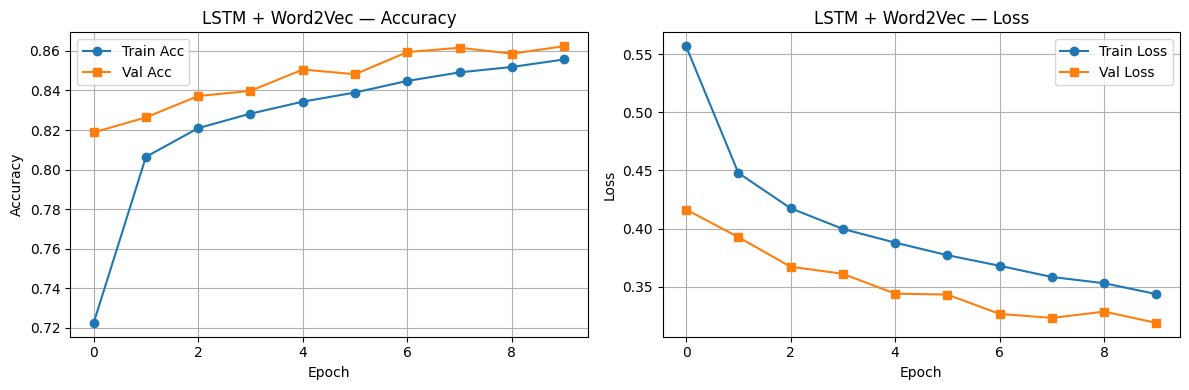

In [18]:
import matplotlib.pyplot as plt

# Plot training curves (accuracy & loss) for a given model history
def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history['accuracy'],     label='Train Acc', marker='o')
    axes[0].plot(hist.history['val_accuracy'], label='Val Acc',   marker='s')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True)
    axes[1].plot(hist.history['loss'],     label='Train Loss', marker='o')
    axes[1].plot(hist.history['val_loss'], label='Val Loss',   marker='s')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    safe = title.replace(' ','_').replace('+','plus')
    plt.savefig(f'history_{safe}.png', dpi=150)
    plt.show()

plot_history(hist_rnn,  'Simple RNN')
plot_history(hist_lstm, 'LSTM (trainable embedding)')
plot_history(hist_w2v,  'LSTM + Word2Vec')

3. Model Evaluation on Test Set


  Simple RNN
  Test Accuracy : 0.5045

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67      5000
    Positive       0.75      0.01      0.03      5000

    accuracy                           0.50     10000
   macro avg       0.63      0.50      0.35     10000
weighted avg       0.63      0.50      0.35     10000



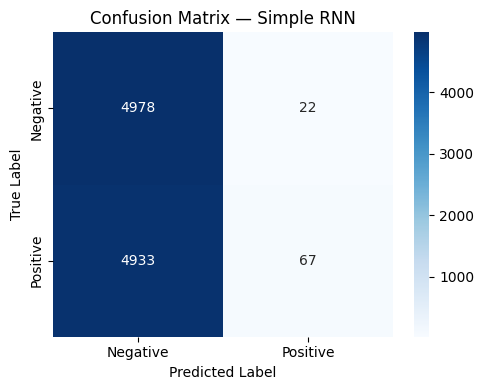


  LSTM (trainable)
  Test Accuracy : 0.8780

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.84      0.87      5000
    Positive       0.85      0.92      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



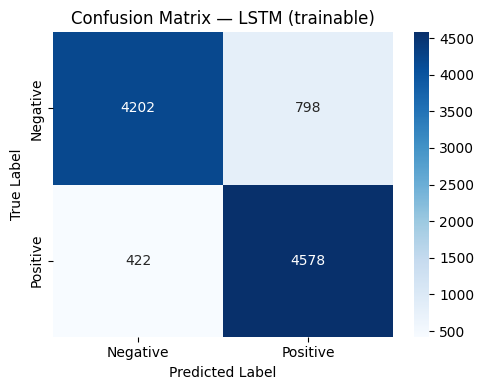


  LSTM + Word2Vec
  Test Accuracy : 0.8594

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85      5000
    Positive       0.84      0.89      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



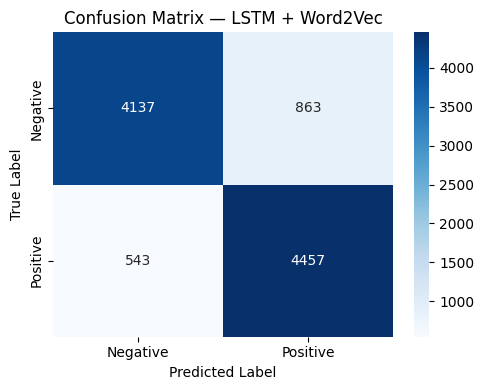

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate model and display accuracy, classification report, and confusion matrix
def evaluate_model(model, X, y, model_name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    acc    = accuracy_score(y, y_pred)

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy : {acc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y, y_pred,
          target_names=['Negative', 'Positive']))

    # Plot confusion matrix as heatmap
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    safe = model_name.replace(' ','_').replace('+','plus')
    plt.savefig(f'cm_{safe}.png', dpi=150)
    plt.show()

    return y_pred, acc

# Evaluate all three models on test set
y_pred_rnn,  acc_rnn  = evaluate_model(rnn_model,  X_test, y_test, 'Simple RNN')
y_pred_lstm, acc_lstm = evaluate_model(lstm_model, X_test, y_test, 'LSTM (trainable)')
y_pred_w2v,  acc_w2v  = evaluate_model(lstm_w2v,   X_test, y_test, 'LSTM + Word2Vec')

4. Compare the performance of the Model

           Model  Test Accuracy  Training Time
      Simple RNN         0.5045      91.609947
LSTM (trainable)         0.8780    2143.766396
 LSTM + Word2Vec         0.8594    3619.057387


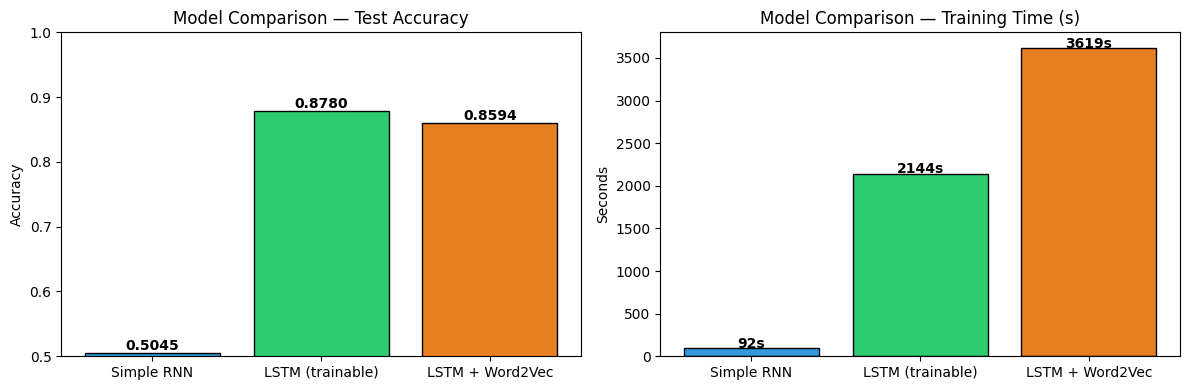

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Create summary DataFrame with all three model results
results = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM (trainable)', 'LSTM + Word2Vec'],
    'Test Accuracy': [acc_rnn, acc_lstm, acc_w2v],
    'Training Time': [rnn_time, lstm_time, w2v_time],
})

print(results.to_string(index=False))


# Create side-by-side bar charts for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results['Model'], results['Test Accuracy'],
            color=['#3498db','#2ecc71','#e67e22'], edgecolor='black')
axes[0].set_title('Model Comparison — Test Accuracy')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(results['Test Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(results['Model'], results['Training Time'],
            color=['#3498db','#2ecc71','#e67e22'], edgecolor='black')
axes[1].set_title('Model Comparison — Training Time (s)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(results['Training Time']):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## C. Error Analysis

In [21]:
import numpy as np

# Find best performing model based on test accuracy
best_idx  = results['Test Accuracy'].idxmax()
best_name = results.iloc[best_idx]['Model']
print(f'Best model: {best_name}')

# Map model names to their predictions
preds_map = {
    'Simple RNN'      : y_pred_rnn,
    'LSTM (trainable)': y_pred_lstm,
    'LSTM + Word2Vec' : y_pred_w2v,
}
y_pred_best = preds_map[best_name]

# Identify misclassifications
fp_mask = (y_test == 0) & (y_pred_best == 1)
fn_mask = (y_test == 1) & (y_pred_best == 0)

print(f'False Positives (predicted Positive, actually Negative): {fp_mask.sum()}')
print(f'False Negatives (predicted Negative, actually Positive): {fn_mask.sum()}')

# Display sample False Positives
print('\n=== Sample False Positives (Predicted POSITIVE, Actually NEGATIVE) ===')
for idx in np.where(fp_mask)[0][:3]:
    print(f'\nReview  : {str(X_test_raw[idx])[:200]}')
    print(f'True: NEGATIVE | Predicted: POSITIVE')

# Display sample False Negatives
print('\n=== Sample False Negatives (Predicted NEGATIVE, Actually POSITIVE) ===')
for idx in np.where(fn_mask)[0][:3]:
    print(f'\nReview  : {str(X_test_raw[idx])[:200]}')
    print(f'True: POSITIVE | Predicted: NEGATIVE')

# ── Model Complexity vs Performance ───────────────────────────────────────
print('\n\n=== Model Complexity vs. Performance ===')
complexity = pd.DataFrame({
    'Model'         : ['Simple RNN', 'LSTM (trainable)', 'LSTM + Word2Vec'],
    'Test Accuracy' : [acc_rnn, acc_lstm, acc_w2v],
    'Training Time' : [f'{rnn_time:.1f}s', f'{lstm_time:.1f}s', f'{w2v_time:.1f}s'],
    'Embedding'     : ['Trainable', 'Trainable', 'Frozen Word2Vec'],
    'Recurrent Layer': ['SimpleRNN', 'LSTM', 'LSTM'],
    'Parameters'    : [
        f'{rnn_model.count_params():,}',
        f'{lstm_model.count_params():,}',
        f'{lstm_w2v.count_params():,}'
    ]
})
print(complexity.to_string(index=False))
print(f'\nBest Model  : {best_name}')
print(f'Best Accuracy: {results["Test Accuracy"].max():.4f}')

Best model: LSTM (trainable)
False Positives (predicted Positive, actually Negative): 798
False Negatives (predicted Negative, actually Positive): 422

=== Sample False Positives (Predicted POSITIVE, Actually NEGATIVE) ===

Review  : ...had I watched it in my teenage years. This movie was mildly entertaining. What I liked about Soul Survivors were the gothic atmosphere during the party scenes, and the constant flips between 'dream
True: NEGATIVE | Predicted: POSITIVE

Review  : I have to admit I laughed a few times during this trivial 2004 holiday movie, but it's already moving out of my short-term memory. In a career that is sliding rather swiftly toward tabloid obscurity, 
True: NEGATIVE | Predicted: POSITIVE

Review  : The tenuous connection between this film and the first Grease is established right at the beginning of the film when Didi Conn one of four cast members repeating their roles approaches young Maxwell C
True: NEGATIVE | Predicted: POSITIVE

=== Sample False Negatives (P

Possible reasons for errors:

False positives occur when reviews contain mixed language. For example, a review saying "disappointing, weak cast, poorly written" also contains neutral words like "Star Trek" or "important" which confuse the model. False negatives happen when reviews use hedging phrases like "could have been one of the best" or "slightly uneven" which pull the prediction negative despite positive intent. Domain-specific words like "Summerslam" and "Purgatory" appear as OOV tokens, removing useful context. The model also cannot detect sarcasm or irony, so qualified criticism is frequently misclassified.


Model Complexity vs. Performance:

Simple RNN has the fewest parameters and trains fastest but achieves the lowest accuracy, struggling with long reviews due to vanishing gradients. LSTM with trainable embeddings achieved the best accuracy as its gating mechanism handles long-range dependencies better. LSTM with Word2Vec uses frozen pretrained embeddings which provide a strong starting point but cannot adapt to movie-review specific vocabulary, limiting its final accuracy.



Suggested improvements:

A Bidirectional LSTM would capture both forward and backward context in reviews. An attention mechanism would help the model focus on the most sentiment-rich words. Fine-tuning a pretrained transformer like BERT would likely achieve state-of-the-art performance. Data augmentation for mixed-sentiment reviews would also help reduce misclassifications on borderline cases.

## 13. Bonus — Gradio GUI for Real-Time Sentiment Prediction

In [22]:
import re
import gradio as gr
import contractions
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Clean and preprocess raw review text
def clean_review(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = contractions.fix(text)                # Expand contractions
    text = text.lower()                          # Convert to lowercase
    text = re.sub(r'<[^>]+>', ' ', text)         # Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)        # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()     # Normalize whitespace


    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

# Select best model based on earlier comparison
best_model_obj = {
    'Simple RNN'      : rnn_model,
    'LSTM (trainable)': lstm_model,
    'LSTM + Word2Vec' : lstm_w2v,
}[best_name]

# Prediction function for Gradio interface
def predict_review(review_text):
    if not review_text.strip():
        return 'Please enter a movie review.', None
    cleaned = clean_review(review_text)
    if not cleaned:
        return 'After cleaning, no usable text remained.', None
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba  = float(best_model_obj.predict(padded, verbose=0).flatten()[0])
    label  = '😊 POSITIVE' if proba > 0.5 else '😠 NEGATIVE'
    conf   = proba if proba > 0.5 else 1 - proba
    result = f'{label}  (confidence: {conf:.1%})'
    return result, {'Negative': 1 - proba, 'Positive': proba}

# Create Gradio web interface
demo = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=5, placeholder='Paste a movie review here...', label='Movie Review'),
    outputs=[
        gr.Textbox(label='Sentiment Prediction'),
        gr.Label(label='Class Probabilities'),
    ],
    title=f'Movie Review Sentiment Classifier — {best_name}',
    description='Enter a movie review and the model predicts whether it is Positive or Negative.',
    examples=[
        ['An absolute masterpiece. The performances were breathtaking and the cinematography stunning.'],
        ['Terrible movie. The plot made no sense and the acting was wooden throughout.'],
        ['It was okay. Some good moments but overall felt like a missed opportunity.'],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://834d15ef6c05c950ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
